/var/folders/_9/wb6xnpp934vc9w0g88_c9nhh0000gn/T/ipykernel_90066/3397657235.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('eval_type', group_keys=False).apply(fix_global_rank)


CSV updated with corrected global 'rank_of_median_auc'.

Saved: replicate_results/Heatmap_MedianRank_Stratified.png


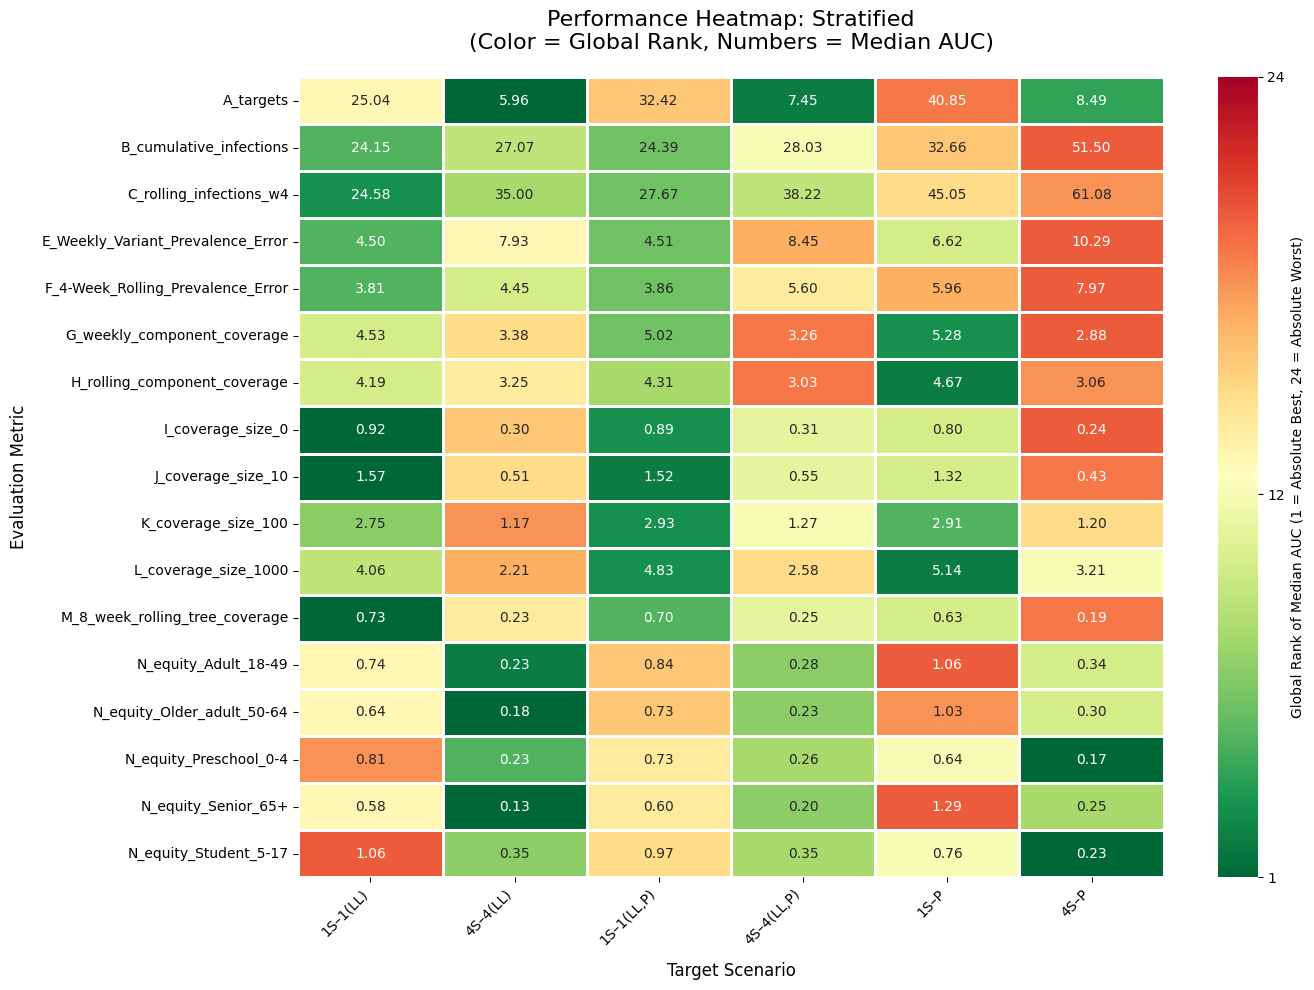

Saved: replicate_results/Heatmap_MedianRank_LASSO-Greedy.png


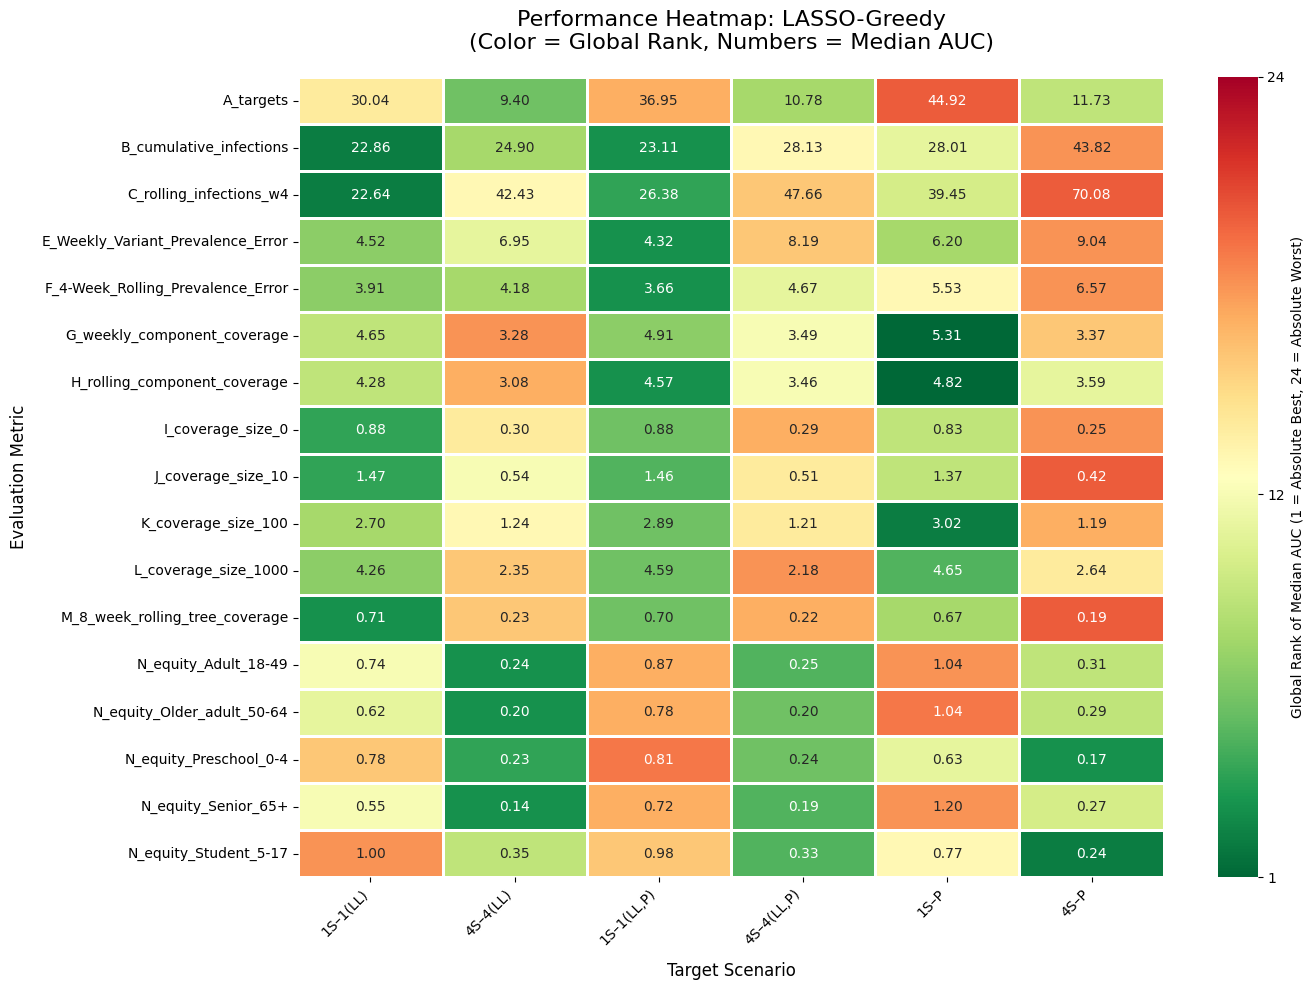

Saved: replicate_results/Heatmap_MedianRank_LASSO-Stratified.png


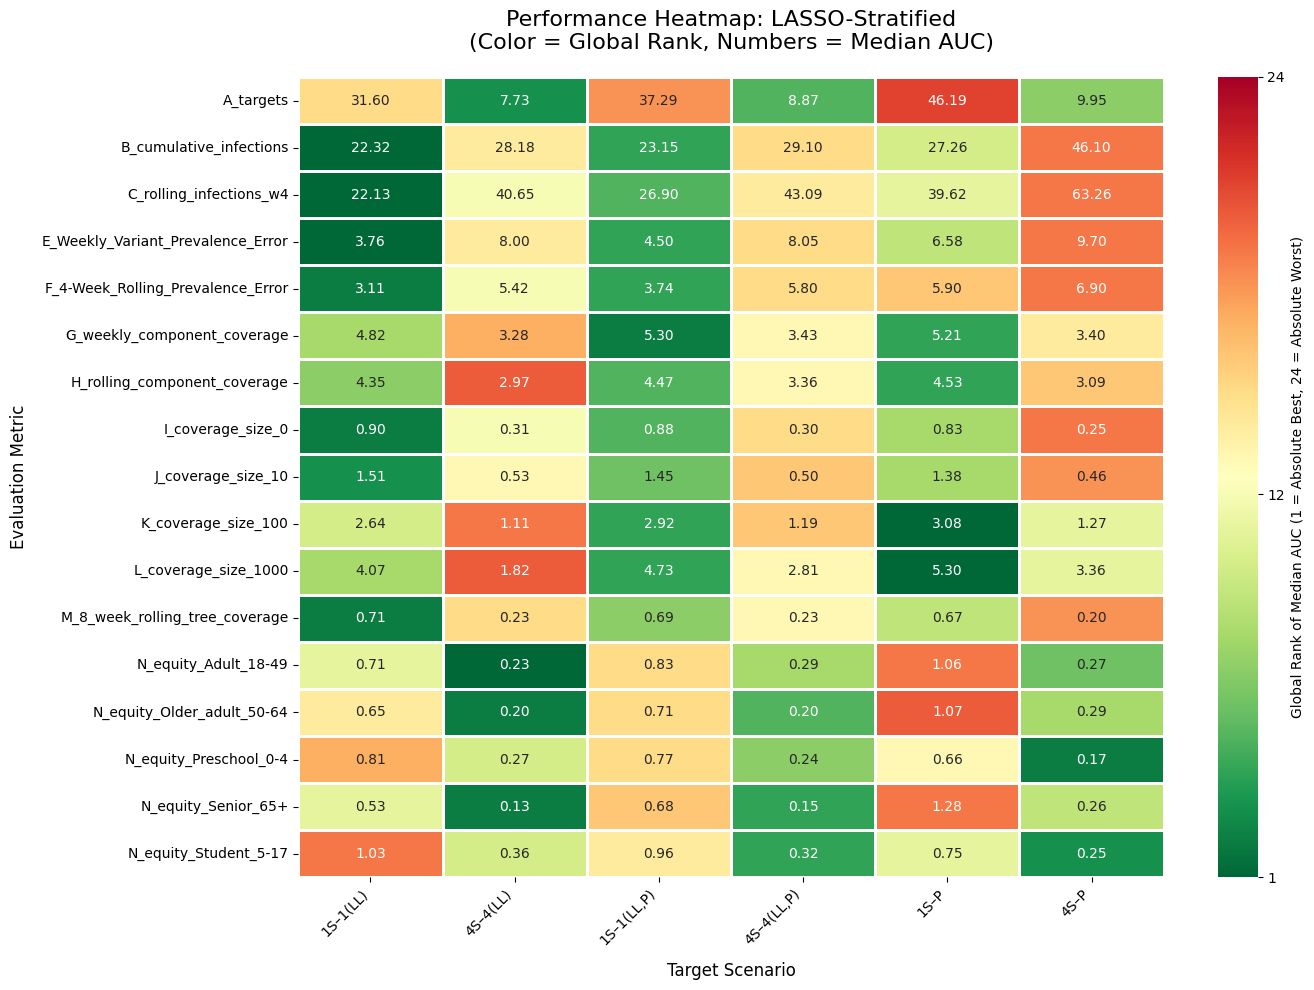

Saved: replicate_results/Heatmap_MedianRank_SURS.png


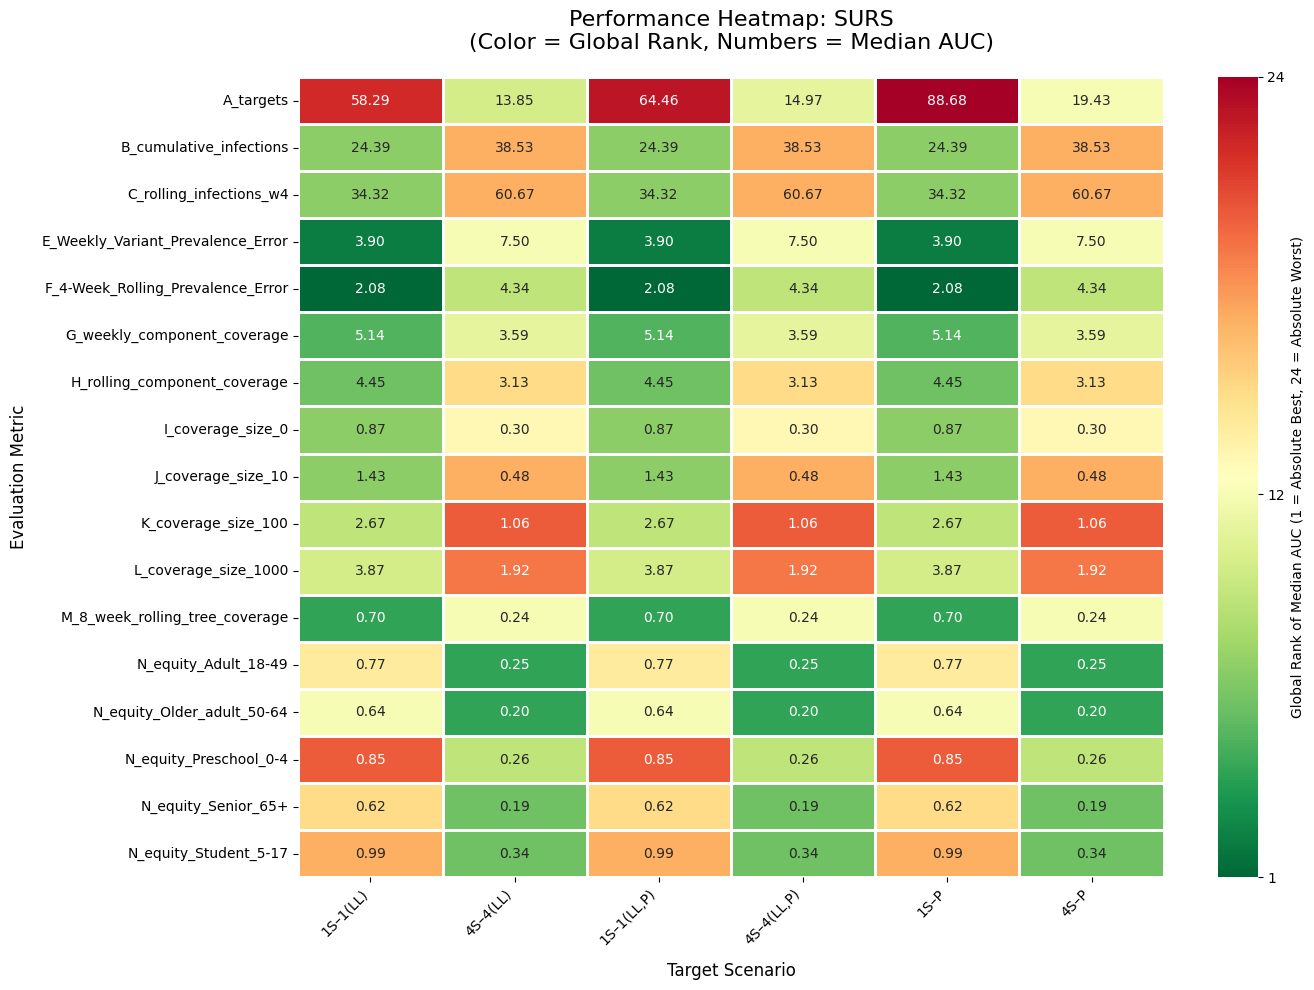

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. Hardcode your input and output paths here
# ==========================================
input_file = "./replicate_results/Aggregated_Median_AUC_Rankings.csv" 
output_directory = "heatmap_replicate_results"

input_path = Path(input_file)
outdir = Path(output_directory)
outdir.mkdir(parents=True, exist_ok=True)

if not input_path.exists():
    print(f"Error: Could not find '{input_path}'. Please check the path.")
else:
    # 2. Load data
    df = pd.read_csv(input_path)

    # 3. Define which metrics are "Higher is Better" (Coverage scores)
    higher_is_better_prefixes = ('G_', 'H_', 'I_', 'J_', 'K_', 'L_', 'M_')

    # ==========================================
    # FIX: Correct the inverted rankings in the CSV
    # ==========================================
    def fix_global_rank(group):
        eval_type = group['eval_type'].iloc[0]
        asc = not eval_type.startswith(higher_is_better_prefixes)
        
        # Calculate the true global rank based on median_auc
        group['rank_of_median_auc'] = group['median_auc'].rank(method="dense", ascending=asc)
        return group

    # Apply the fix grouped ONLY by eval_type (this compares all 18 combinations)
    df = df.groupby('eval_type', group_keys=False).apply(fix_global_rank)
    df.to_csv(input_path, index=False)
    print("CSV updated with corrected global 'rank_of_median_auc'.\n")
    # ==========================================

    # Sort to ensure our axes stay in logical alphabetical/numerical order
    df = df.sort_values(by=['eval_type', 'scenario_id'])

    # 4. Generate a plot for each algorithm
    algorithms = df['algorithm'].unique()
    
    # The maximum rank is the highest number found in the rank_of_median_auc column
    max_rank = int(df['rank_of_median_auc'].max())

    for algo in algorithms:
        algo_df = df[df['algorithm'] == algo]

        # Create matrices for Seaborn
        # COLOR = rank_of_median_auc
        rank_pivot = algo_df.pivot(index='eval_type', columns='scenario_label', values='rank_of_median_auc')
        # TEXT = median_auc
        auc_pivot = algo_df.pivot(index='eval_type', columns='scenario_label', values='median_auc')

        # Keep columns (scenarios) strictly ordered by scenario_id
        ordered_scenarios = algo_df[['scenario_id', 'scenario_label']].drop_duplicates().sort_values('scenario_id')['scenario_label']
        rank_pivot = rank_pivot[ordered_scenarios]
        auc_pivot = auc_pivot[ordered_scenarios]

        # 5. Plotting
        plt.figure(figsize=(14, 10))
        
        ax = sns.heatmap(
            rank_pivot, 
            annot=auc_pivot, 
            fmt=".2f",          
            cmap="RdYlGn_r", 
            vmin=1, 
            vmax=max_rank, 
            linewidths=1,
            linecolor='white',
            cbar_kws={
                'ticks': [1, max_rank // 2, max_rank], 
                'label': f'Global Rank of Median AUC (1 = Absolute Best, {max_rank} = Absolute Worst)'
            }
        )

        plt.title(f"Performance Heatmap: {algo}\n(Color = Global Rank, Numbers = Median AUC)", fontsize=16, pad=20)
        plt.xlabel("Target Scenario", fontsize=12, labelpad=10)
        plt.ylabel("Evaluation Metric", fontsize=12, labelpad=10)
        
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        # Save to disk
        out_file = outdir / f"Heatmap_MedianRank_{algo}.png"
        plt.savefig(out_file, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_file}")
        
        # Display inline in the Jupyter Notebook
        plt.show()

/tmp/ipykernel_633607/2303671473.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('eval_type', group_keys=False).apply(process_metrics)


CSV updated with corrected ranks and new z-scores.

Saved: replicate_results/Heatmap_Combined_RankAndZ.png


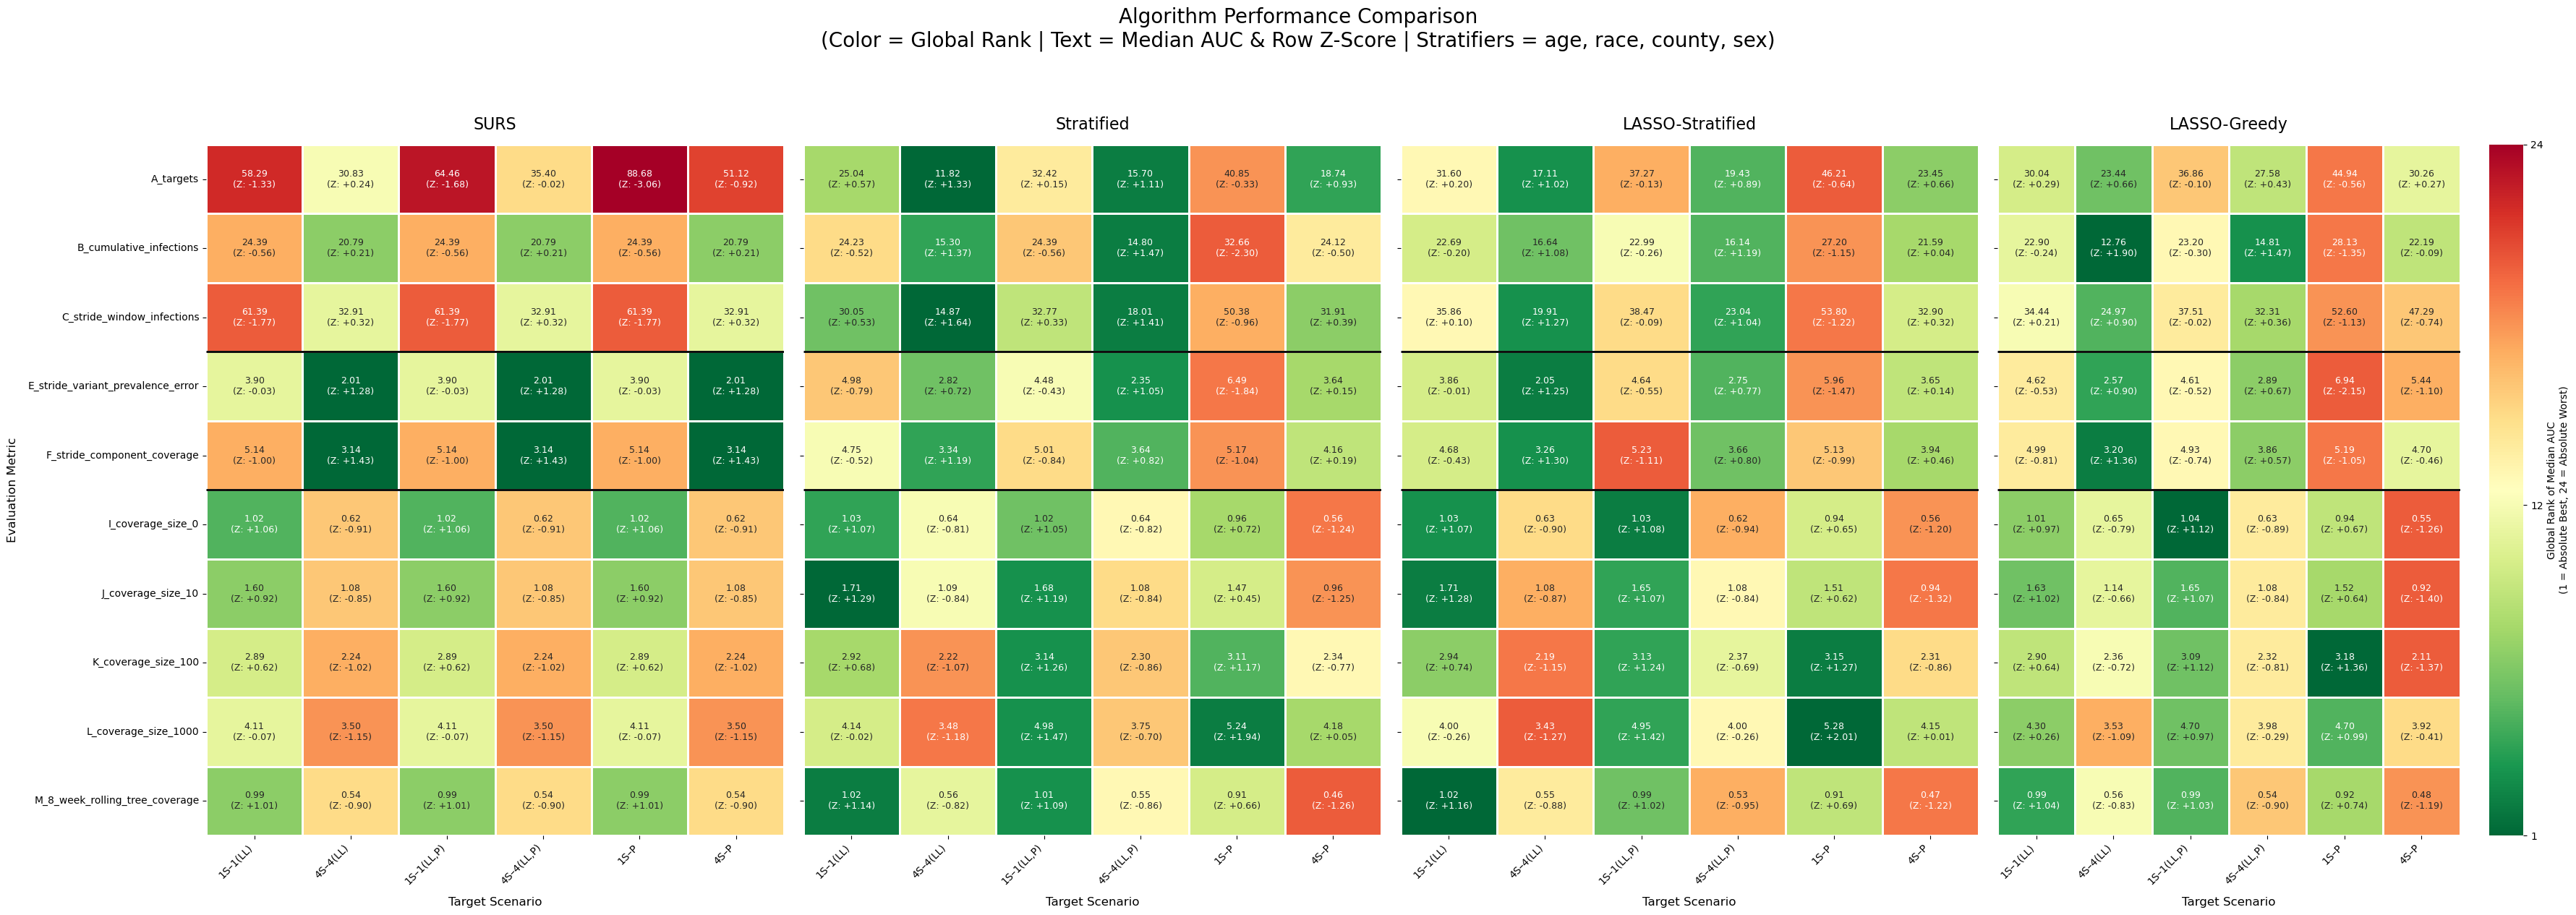


RANKING: Sum of Z-Scores across panels A, C, E, F, K, M
(Higher sum = better overall; one metric per eval family)
Rank  Algorithm                Scenario             Sum Z    Mean Z  #Panels
--------------------------------------------------------------------------------
#1    Stratified               4S–4(LL)             2.989     0.498        6
#2    LASSO-Stratified         4S–4(LL)             2.819     0.470        6
#3    Stratified               4S–4(LL,P)           2.669     0.445        6
#4    LASSO-Greedy             4S–4(LL)             2.283     0.381        6
#5    LASSO-Stratified         4S–4(LL,P)           1.862     0.310        6
#6    LASSO-Stratified         1S–1(LL)             1.761     0.293        6
#7    Stratified               1S–1(LL)             1.620     0.270        6
#8    Stratified               1S–1(LL,P)           1.555     0.259        6
#9    SURS                     4S–4(LL)             1.353     0.225        6
#10   SURS                     4S–

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. Hardcode your input and output paths here
# ==========================================
input_file = "./replicate_results/Aggregated_Median_AUC_Rankings.csv" 
output_directory = "replicate_results"

input_path = Path(input_file)
outdir = Path(output_directory)
outdir.mkdir(parents=True, exist_ok=True)

if not input_path.exists():
    print(f"Error: Could not find '{input_path}'. Please check the path.")
else:
    # 2. Load data
    df = pd.read_csv(input_path)
    df = df[~df['eval_type'].str.startswith('N_', na=False)].copy()

    # 3. Define which metrics are "Higher is Better"
    higher_is_better_prefixes = ('G_', 'H_', 'I_', 'J_', 'K_', 'L_', 'M_')

    # ==========================================
    # 4. Calculate Rank (Color) AND Z-Score (Text)
    # ==========================================
    def process_metrics(group):
        eval_type = group['eval_type'].iloc[0]
        # asc = True means "Lower is Better" (KL, Error)
        asc = not eval_type.startswith(higher_is_better_prefixes)
        
        # A. Rank for the Color Scale (1 to max combinations)
        group['rank_of_median_auc'] = group['median_auc'].rank(method="dense", ascending=asc)
        
        # B. Row-wise Z-score for the Text Annotation
        mean_val = group['median_auc'].mean()
        std_val = group['median_auc'].std()
        
        if std_val == 0 or pd.isna(std_val):
            group['z_score'] = 0.0
        else:
            z = (group['median_auc'] - mean_val) / std_val
            # Invert Z so Positive (+) ALWAYS means "Better than average"
            if asc: 
                z = -z
            group['z_score'] = z
            
        return group

    # Apply both calculations grouped ONLY by eval_type
    df = df.groupby('eval_type', group_keys=False).apply(process_metrics)

    # C. Create the combined text string for the annotations
    # Example: "41.23\n(Z: +1.50)"
    df['annot_str'] = df.apply(lambda row: f"{row['median_auc']:.2f}\n(Z: {row['z_score']:+.2f})", axis=1)

    # Overwrite CSV to save the corrected ranks and z-scores
    df.to_csv(input_path, index=False)
    print("CSV updated with corrected ranks and new z-scores.\n")

    # Sort to ensure axes stay in logical order
    df = df.sort_values(by=['eval_type', 'scenario_id'])

    # 5. Setup the combined subplots
    desired_order = ["SURS", "Stratified", "LASSO-Stratified"]
    
    available_algos = df['algorithm'].unique()
    algorithms = [algo for algo in desired_order if algo in available_algos]
    for algo in available_algos:
        if algo not in algorithms:
            algorithms.append(algo)

    n_algos = len(algorithms)
    max_rank = int(df['rank_of_median_auc'].max())

    # Create a figure with 1 row and 'n_algos' columns. Share the Y-axis.
    fig, axes = plt.subplots(1, n_algos, figsize=(9 * n_algos, 12), sharey=True)
    if n_algos == 1:
        axes = [axes]

    # 6. Loop through and plot each algorithm on its own axis
    for i, (algo, ax) in enumerate(zip(algorithms, axes)):
        algo_df = df[df['algorithm'] == algo]

        # Matrices for Seaborn
        # COLOR = Global Rank (rank_of_median_auc)
        rank_pivot = algo_df.pivot(index='eval_type', columns='scenario_label', values='rank_of_median_auc')
        # TEXT = Combined String (annot_str)
        annot_pivot = algo_df.pivot(index='eval_type', columns='scenario_label', values='annot_str')

        # Keep columns strictly ordered by scenario_id
        ordered_scenarios = algo_df[['scenario_id', 'scenario_label']].drop_duplicates().sort_values('scenario_id')['scenario_label']
        rank_pivot = rank_pivot[ordered_scenarios]
        annot_pivot = annot_pivot[ordered_scenarios]

        show_cbar = (i == n_algos - 1)

        sns.heatmap(
            rank_pivot, 
            annot=annot_pivot, 
            fmt="",            # Leave blank because our values are already formatted strings
            cmap="RdYlGn_r",   # Green = Rank 1, Red = Rank 18
            vmin=1, 
            vmax=max_rank, 
            linewidths=1,
            linecolor='white',
            annot_kws={"size": 9}, # Slightly smaller text to fit both lines safely
            cbar=show_cbar,
            cbar_kws={
                'ticks': [1, max_rank // 2, max_rank], 
                'label': f'Global Rank of Median AUC\n(1 = Absolute Best, {max_rank} = Absolute Worst)'
            } if show_cbar else None,
            ax=ax
        )

        # only separate after these metric families
        break_after_prefixes = {'C', 'F'}
        
        row_labels = rank_pivot.index.tolist()
        
        for j, label in enumerate(row_labels[:-1]):
            prefix_now = label.split('_')[0]
            if prefix_now in break_after_prefixes:
                ax.hlines(j + 1, *ax.get_xlim(), colors='black', linewidth=2)

        ax.set_title(f"{algo}", fontsize=16, pad=15)
        ax.set_xlabel("Target Scenario", fontsize=12, labelpad=10)
        
        if i == 0:
            ax.set_ylabel("Evaluation Metric", fontsize=12, labelpad=10)
        else:
            ax.set_ylabel("")
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # 7. Add a master title and finalize layout
    fig.suptitle("Algorithm Performance Comparison\n(Color = Global Rank | Text = Median AUC & Row Z-Score | Stratifiers = age, race, county, sex)", fontsize=20, y=1.05)
    plt.tight_layout()

    # Save to disk
    out_file = outdir / "Heatmap_Combined_RankAndZ.png"
    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_file}")
    
    plt.show()

    # ==========================================
    # 8. RANKING: Sum of Z-scores for selected panels
    #    (A, C, F, H, K, M — one representative per eval family)
    # ==========================================
    SELECTED_PREFIXES = ("A_", "C_", "E_", "F_", "K_", "M_")
    df_sel = df[df['eval_type'].str.startswith(SELECTED_PREFIXES)].copy()

    if df_sel.empty:
        print("\n[WARN] No rows matched panels A, C, E, F, K, M. Skipping ranking.")
    else:
        df_sel['algo_scenario'] = df_sel['algorithm'] + " | " + df_sel['scenario_label']

        ranking = (
            df_sel
            .groupby(['algorithm', 'scenario_label', 'algo_scenario'])
            .agg(
                sum_z=('z_score', 'sum'),
                mean_z=('z_score', 'mean'),
                n_metrics=('z_score', 'count'),
            )
            .reset_index()
            .sort_values('sum_z', ascending=False)
        )
        ranking['rank'] = range(1, len(ranking) + 1)

        print("\n" + "=" * 80)
        print("RANKING: Sum of Z-Scores across panels A, C, E, F, K, M")
        print("(Higher sum = better overall; one metric per eval family)")
        print("=" * 80)
        print(f"{'Rank':<6}{'Algorithm':<25}{'Scenario':<16}{'Sum Z':>10}{'Mean Z':>10}{'#Panels':>9}")
        print("-" * 80)
        for _, row in ranking.iterrows():
            print(
                f"#{int(row['rank']):<5}"
                f"{row['algorithm']:<25}"
                f"{row['scenario_label']:<16}"
                f"{row['sum_z']:>10.3f}"
                f"{row['mean_z']:>10.3f}"
                f"{int(row['n_metrics']):>9}"
            )

        # Best scenario per algorithm
        print("\n" + "-" * 80)
        print("BEST SCENARIO PER ALGORITHM:")
        print("-" * 80)
        best = ranking.loc[ranking.groupby('algorithm')['sum_z'].idxmax()]
        best = best.sort_values('sum_z', ascending=False)
        for _, row in best.iterrows():
            print(f"  {row['algorithm']:<25} → {row['scenario_label']:<16} (sum_z = {row['sum_z']:+.3f})")

        # Save ranking CSV
        rank_csv = outdir / "Ranking_Selected_Panels_ACFHKM.csv"
        ranking.to_csv(rank_csv, index=False)
        print(f"\nSaved ranking: {rank_csv}")


Saved: replicate_results/Summary_Trajectory_by_Metric.png


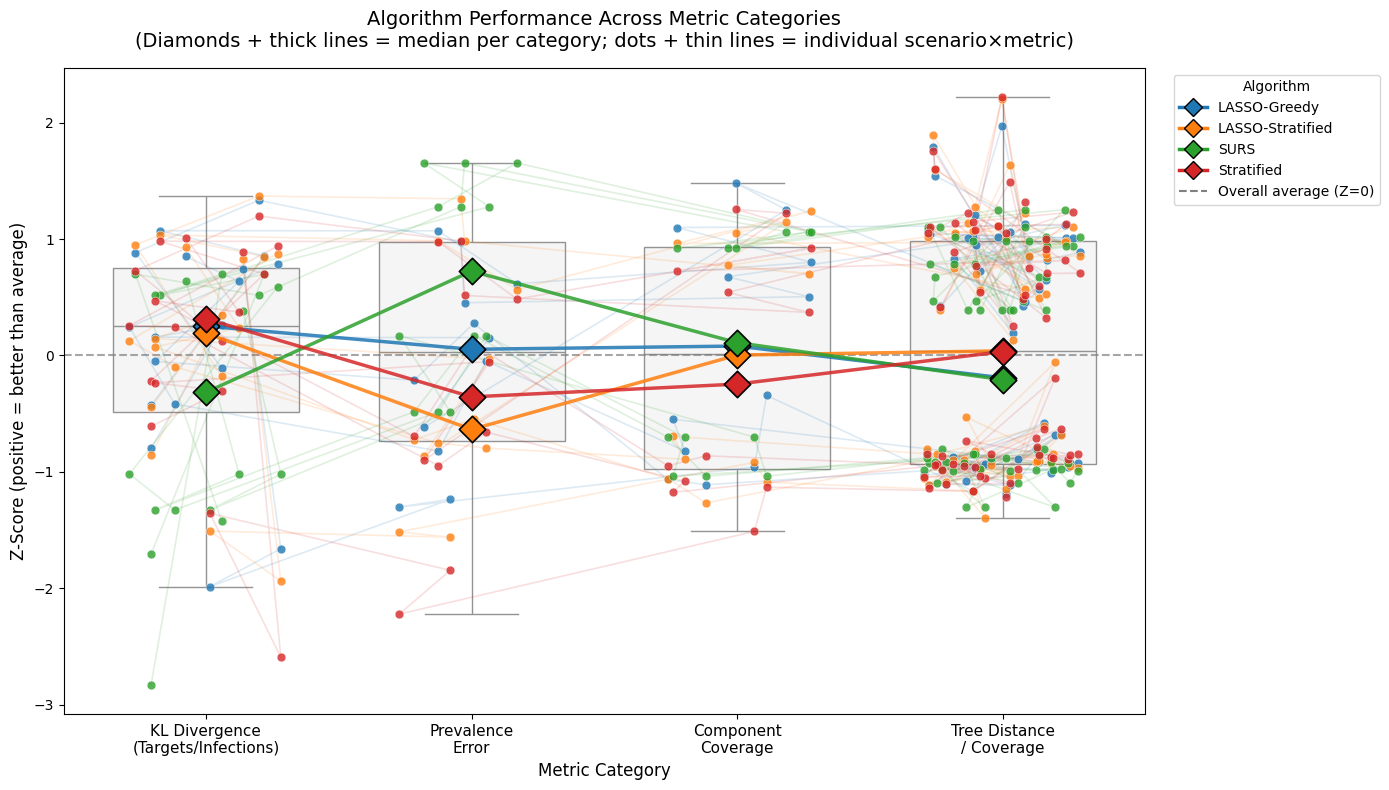

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. Load the data
# ==========================================
input_file = "Aggregated_Median_AUC_Rankings.csv"
df = pd.read_csv(input_file)

if 'z_score' not in df.columns:
    print("Error: 'z_score' column missing. Please run the heatmap script first.")
else:
    # ==========================================
    # 2. Map Metrics to Categories
    # ==========================================
    def assign_category(eval_type):
        if eval_type.startswith(('A_', 'B_', 'C_')):
            return "KL Divergence\n(Targets/Infections)"
        elif eval_type.startswith(('E_', 'F_')):
            return "Prevalence\nError"
        elif eval_type.startswith(('G_', 'H_')):
            return "Component\nCoverage"
        elif eval_type.startswith(('I_', 'J_', 'K_', 'L_', 'M_', 'N_')):
            return "Tree Distance\n/ Coverage"
        else:
            return "Other"

    df['metric_category'] = df['eval_type'].apply(assign_category)

    # Unique task = one (eval_type, scenario) combo
    df['task_id'] = df['eval_type'] + "_" + df['scenario_label']

    # ==========================================
    # 3. Order metric categories on x-axis
    # ==========================================
    cat_order = [
        "KL Divergence\n(Targets/Infections)",
        "Prevalence\nError",
        "Component\nCoverage",
        "Tree Distance\n/ Coverage",
    ]
    # Keep only categories that exist in data
    cat_order = [c for c in cat_order if c in df['metric_category'].unique()]
    # Append any extras
    for c in df['metric_category'].unique():
        if c not in cat_order:
            cat_order.append(c)

    cat_to_x = {cat: i for i, cat in enumerate(cat_order)}
    df['x_base'] = df['metric_category'].map(cat_to_x)

    # ==========================================
    # 4. Assign colors per algorithm
    # ==========================================
    algo_order = sorted(df['algorithm'].unique())

    # Use a qualitative colormap with good separation
    if len(algo_order) <= 10:
        cmap = plt.get_cmap('tab10')
    else:
        cmap = plt.get_cmap('tab20')
    algo_colors = {algo: cmap(i) for i, algo in enumerate(algo_order)}

    # ==========================================
    # 5. Deterministic jitter per task_id
    # ==========================================
    np.random.seed(42)
    unique_tasks = df['task_id'].unique()
    jitter_map = {task: np.random.uniform(-0.3, 0.3) for task in unique_tasks}
    df['x_jittered'] = df['x_base'] + df['task_id'].map(jitter_map)

    # ==========================================
    # 6. Plot
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 8))

    # A. Boxplot per metric category (background, all algorithms pooled)
    sns.boxplot(
        data=df,
        x='metric_category',
        y='z_score',
        order=cat_order,
        color='whitesmoke',
        width=0.7,
        showfliers=False,
        zorder=1,
        ax=ax,
    )

    ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)

    # B. Draw connecting lines per (algorithm, task_id)
    #    Each task_id spans multiple metric categories — but actually each
    #    task_id lives in exactly one category.  So the "slope" lines connect
    #    the SAME algorithm across different metric categories.
    #
    #    Reframe: for each algorithm, for each scenario_label, draw a line
    #    connecting its z_score across metric categories.
    df['scenario_label_clean'] = df['scenario_label']

    for algo in algo_order:
        algo_df = df[df['algorithm'] == algo]
        color = algo_colors[algo]

        for scen, scen_group in algo_df.groupby('scenario_label_clean'):
            if len(scen_group) < 2:
                continue
            scen_group = scen_group.sort_values('x_base')
            ax.plot(
                scen_group['x_jittered'], scen_group['z_score'],
                color=color, alpha=0.15, linewidth=1.2, zorder=3,
            )

        # Draw dots for ALL points of this algorithm
        ax.scatter(
            algo_df['x_jittered'], algo_df['z_score'],
            color=color, edgecolor='white', linewidth=0.4,
            s=40, alpha=0.8, zorder=4,
        )

    # C. Overlay per-algorithm median markers (large, prominent)
    for algo in algo_order:
        algo_df = df[df['algorithm'] == algo]
        medians = algo_df.groupby('metric_category')['z_score'].median()
        color = algo_colors[algo]

        for cat in cat_order:
            if cat not in medians.index:
                continue
            x = cat_to_x[cat]
            y = medians[cat]
            ax.scatter(
                x, y,
                color=color, edgecolor='black', linewidth=1.2,
                s=180, zorder=6, marker='D',
            )

        # Connect medians with a thick line
        xs = [cat_to_x[c] for c in cat_order if c in medians.index]
        ys = [medians[c] for c in cat_order if c in medians.index]
        if len(xs) >= 2:
            ax.plot(xs, ys, color=color, linewidth=2.5, alpha=0.85, zorder=5)

    # D. Formatting
    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels(cat_order, fontsize=11)
    ax.set_ylabel("Z-Score (positive = better than average)", fontsize=12)
    ax.set_xlabel("Metric Category", fontsize=12)
    ax.set_title(
        "Algorithm Performance Across Metric Categories\n"
        "(Diamonds + thick lines = median per category; dots + thin lines = individual scenario×metric)",
        fontsize=14, pad=15,
    )

    # Legend: one entry per algorithm
    legend_handles = [
        mlines.Line2D([], [], color=algo_colors[a], marker='D', markersize=9,
                       markeredgecolor='black', linestyle='-', linewidth=2.5, label=a)
        for a in algo_order
    ]
    legend_handles.append(
        mlines.Line2D([], [], color='grey', linestyle='--', linewidth=1.5,
                       label='Overall average (Z=0)')
    )
    ax.legend(
        handles=legend_handles, title="Algorithm",
        bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10,
    )

    plt.tight_layout()

    out_file = Path("replicate_results/Summary_Trajectory_by_Metric.png")
    out_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    print(f"\nSaved: {out_file}")
    plt.show()